# EDA and Data Preparation


In [1]:
LOAD_PATH: str = "../data/raw/king_county_houses.csv"
SAVE_PATH: str = "../data/processed/king_county_processed.csv"

IMPORTS


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

### 1. Load dataset and explore statistics


In [3]:
df: pd.DataFrame = pd.read_csv(LOAD_PATH)
df.shape


(21613, 21)

In [4]:
df.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [6]:
df.describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1000102.00,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,75000.00,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370000e+00,9.300000e-01,0.00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.110000e+00,7.700000e-01,0.00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184400e+02,290.00,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,520.00,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.490000e+00,5.400000e-01,1.00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,1.000000e-02,9.000000e-02,0.00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.300000e-01,7.700000e-01,0.00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.410000e+00,6.500000e-01,1.00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


#### 1.2 Check for nulls, duplicates, and parse dates

In [7]:
df.isna().sum().sort_values(ascending=True)


id               0
long             0
lat              0
zipcode          0
yr_renovated     0
yr_built         0
sqft_basement    0
sqft_above       0
grade            0
sqft_living15    0
condition        0
waterfront       0
floors           0
sqft_lot         0
sqft_living      0
bathrooms        0
bedrooms         0
price            0
date             0
view             0
sqft_lot15       0
dtype: int64

In [8]:
# Parse dates into timestamps
df["date"] = pd.to_datetime(df["date"]).map(pd.Timestamp.timestamp)
df[["date"]].head()

,date
0,1.413158e+09
1,1.418083e+09
2,1.424822e+09
3,1.418083e+09
4,1.424218e+09


In [9]:
# Check duplicates
df_duplicate = df.duplicated()
df_id_duplicate = df["id"].duplicated()

print("duplicate_rows:", df_duplicate.sum())
print("duplicate_ids:", df_id_duplicate.sum())

duplicate_rows: 0
duplicate_ids: 177


#### Notes

- There are 177 duplicated `id`s, because the same homes have been on the market multiple times. Since it is not a unique identifier, we cannot use it to re-index. Since it's a meaningless feature, we should drop it
- `date` has been parsed and converted to a timestamp, so temporal effects can be used in correlations and regression.
- `lat`, `long`, and `zipcode` all capture location information, so they might inflate due to collinearity. Since `zipcode` is not a meaningful number but rather a label, we should exclude it from the data for the regression.
- Across columns, there is a lot of variance, so feature scaling is essential before comparing linear-model coefficients.


In [10]:
df = df.drop(columns=["id", "zipcode"])
df.to_csv(SAVE_PATH, index=False)

### 2. Explore data shape


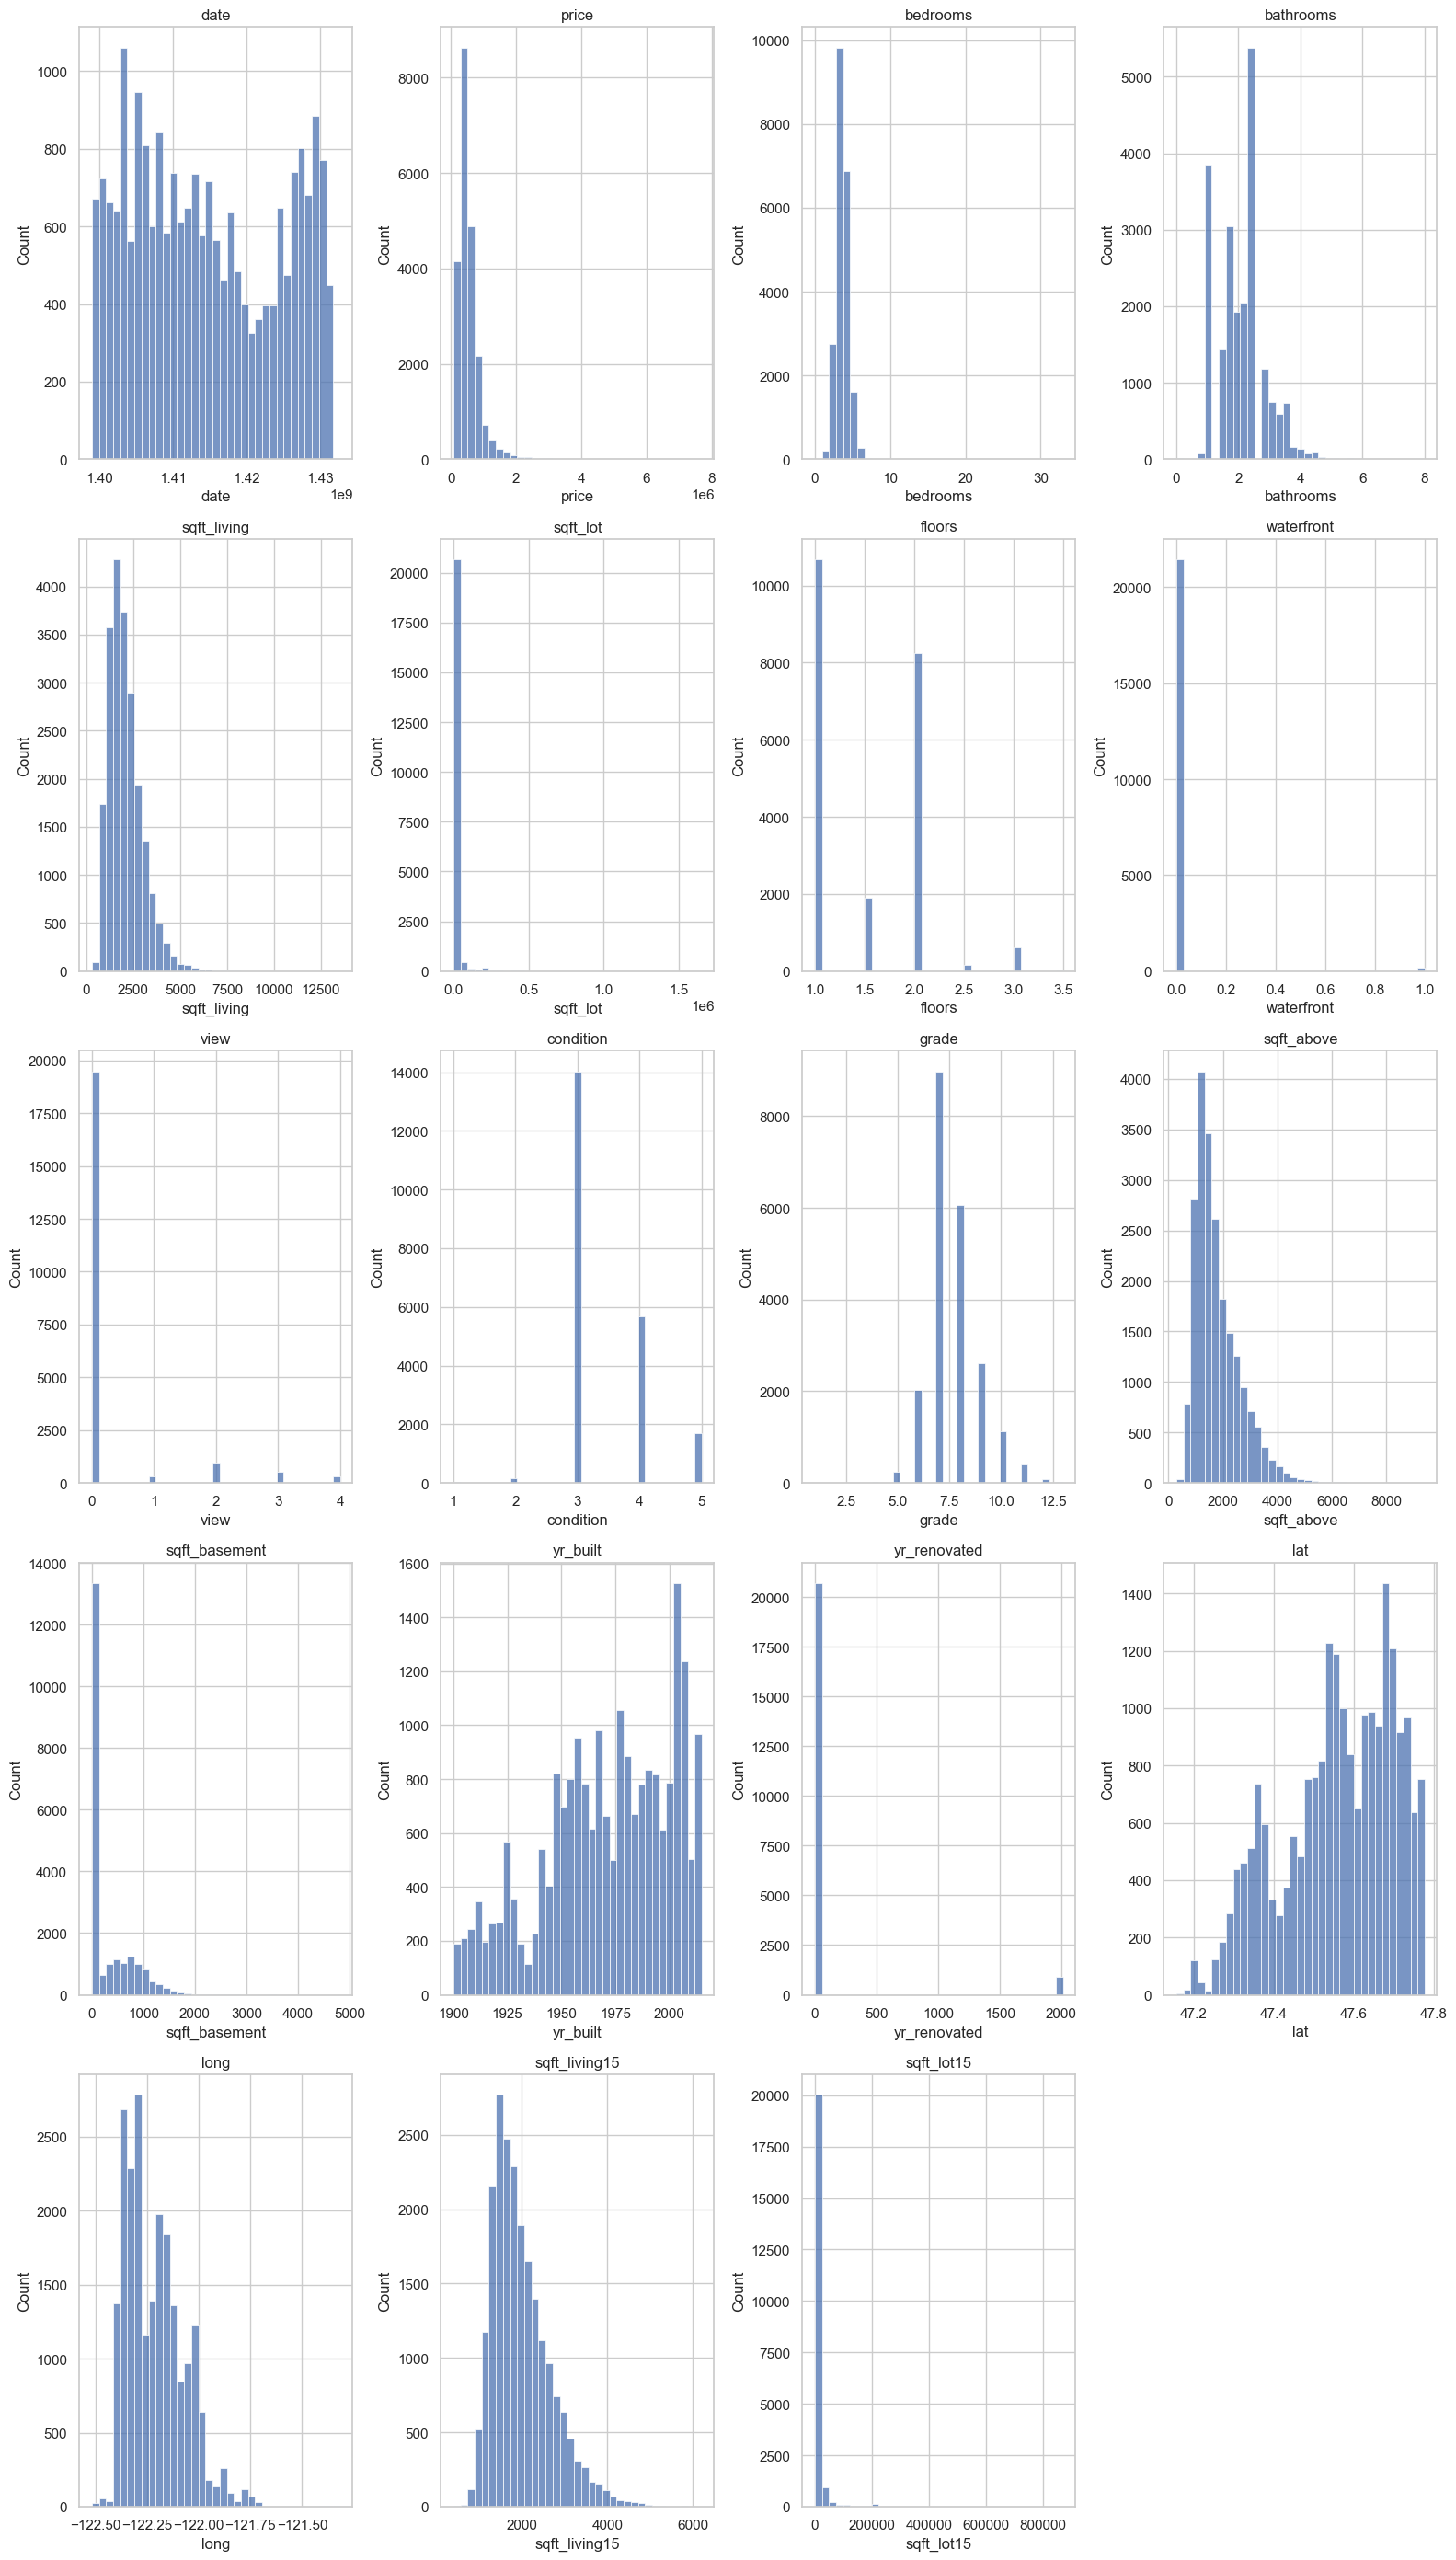

In [11]:
fig, axes = plt.subplots(5, 4, figsize=(16, 28))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], bins=35, ax=axes[i])
    axes[i].set_title(col)

# Hide unused subplots (20 slots, 19 cols)
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

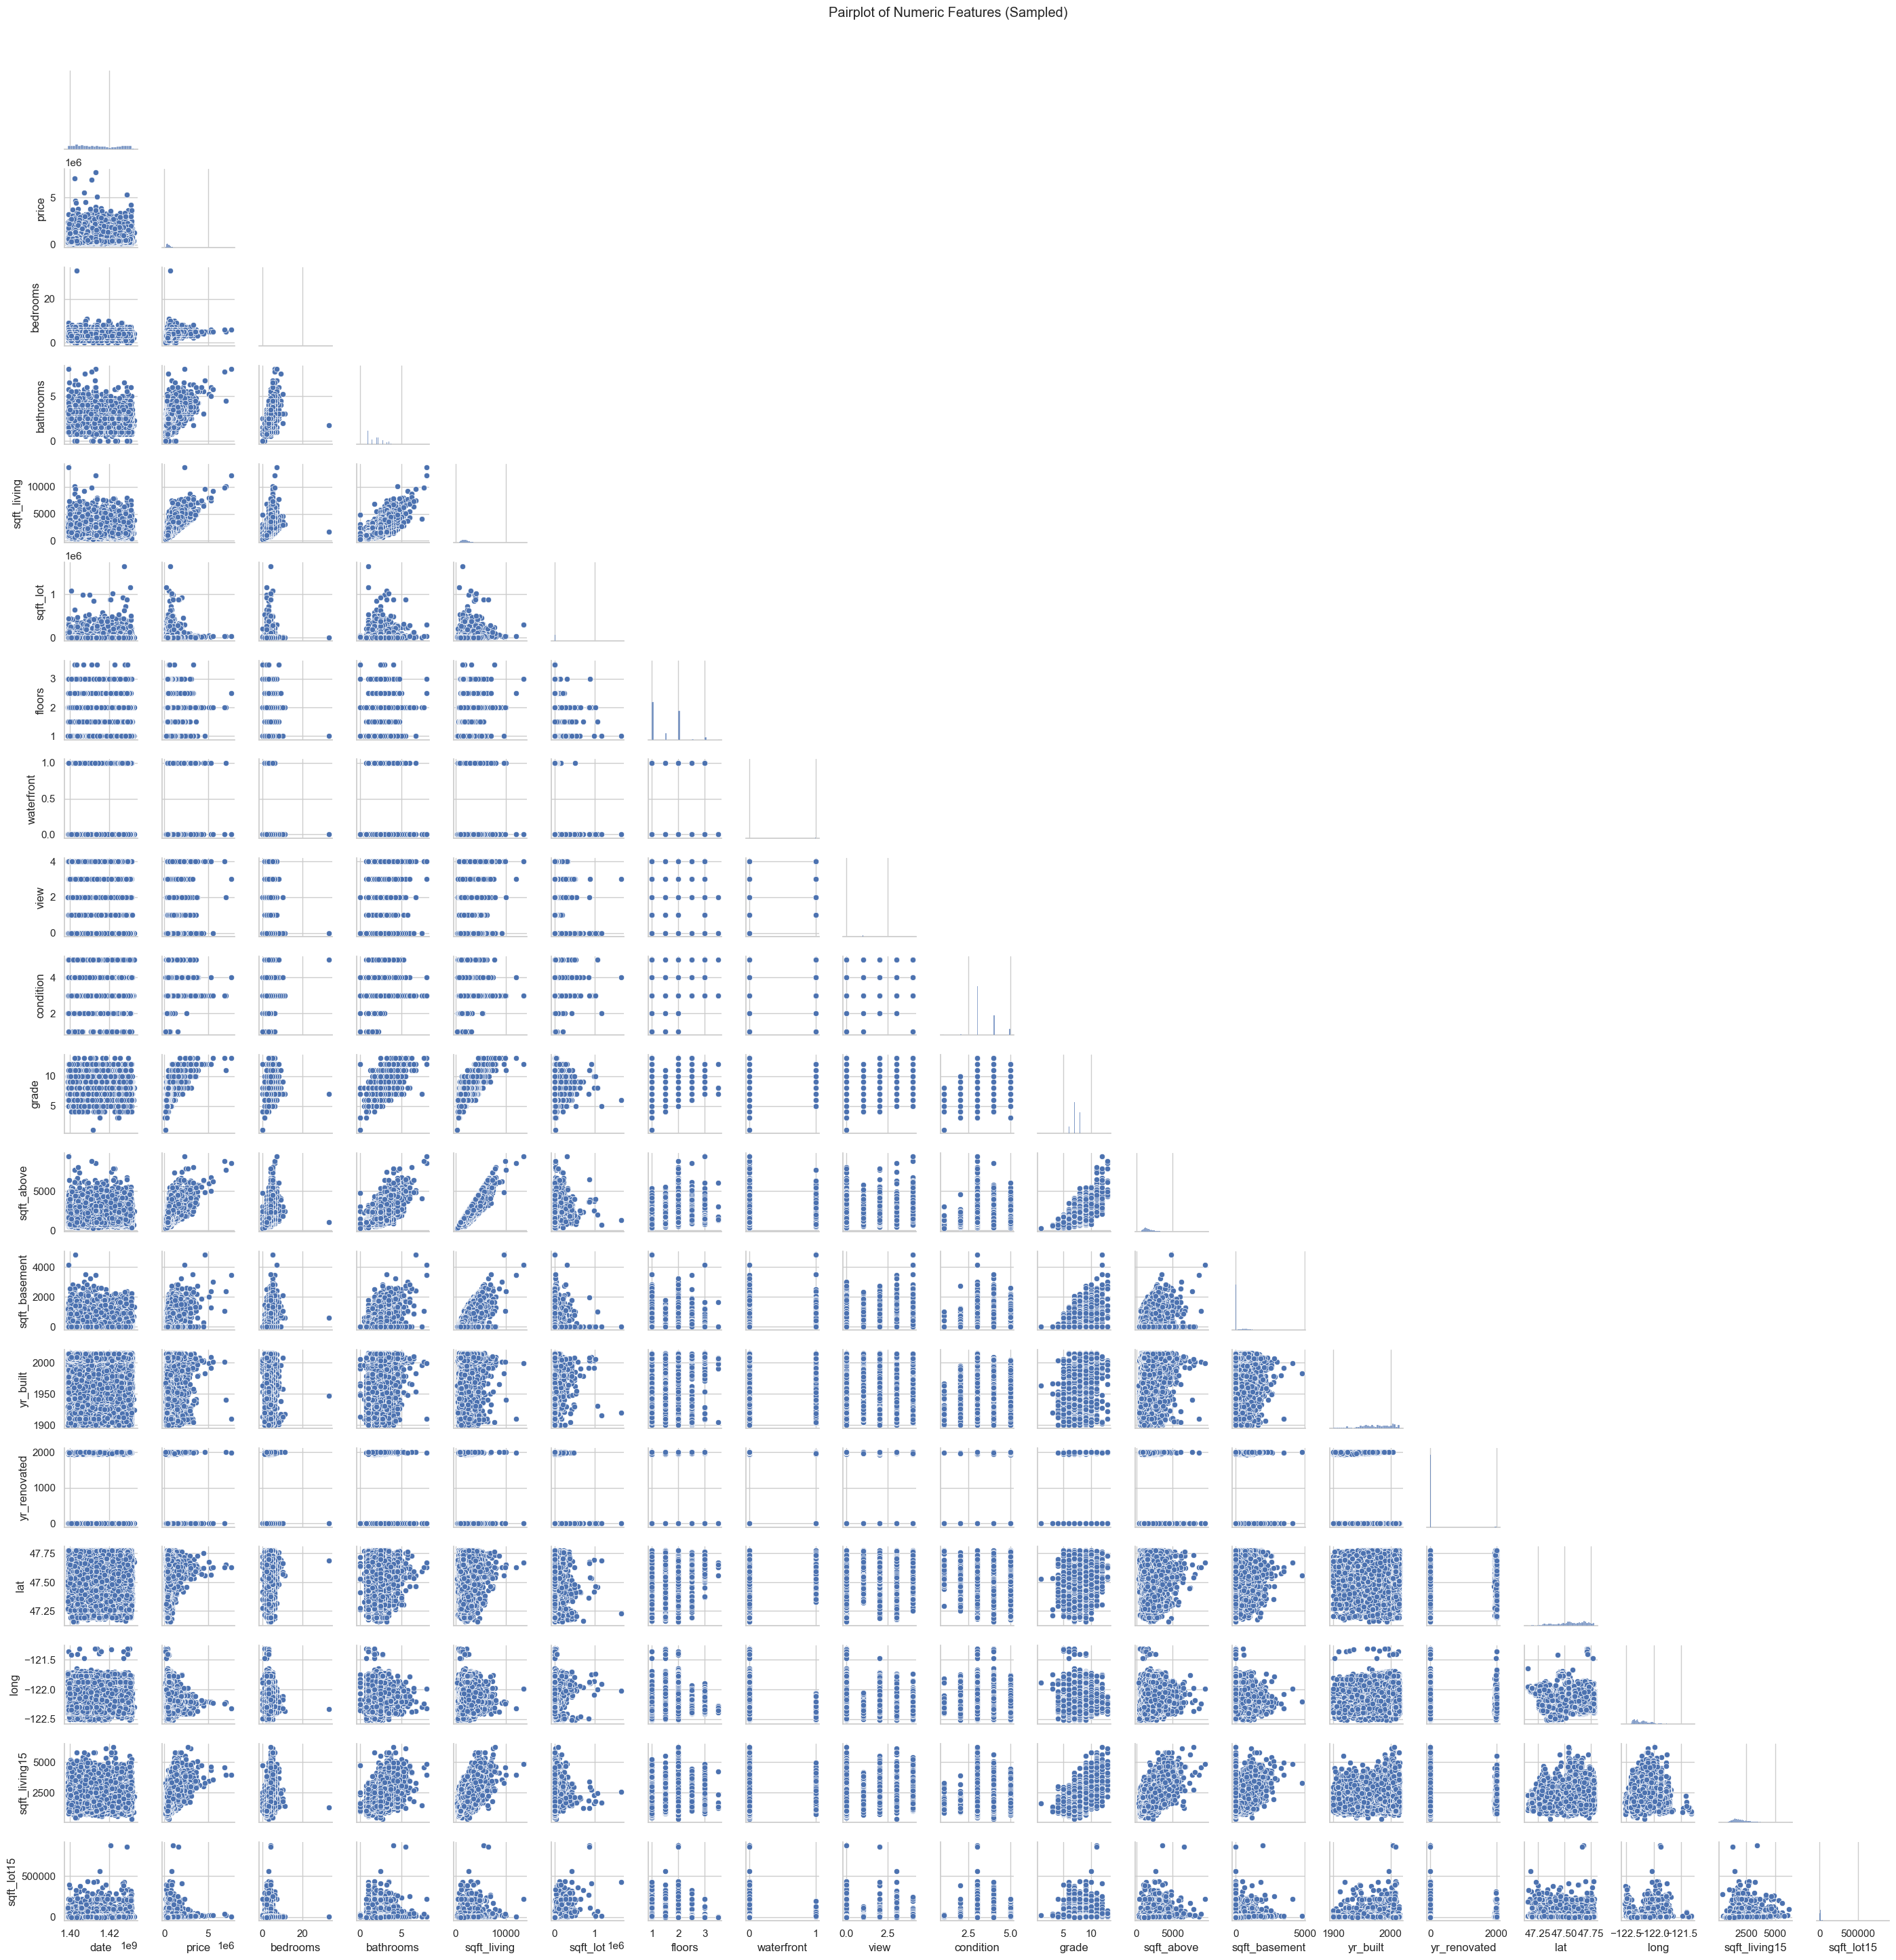

In [12]:
sns.pairplot(
    df,
    corner=True,
    diag_kind="hist",
    height=1.5,
)

plt.suptitle("Pairplot of Numeric Features (Sampled)", y=1.02)
plt.show()


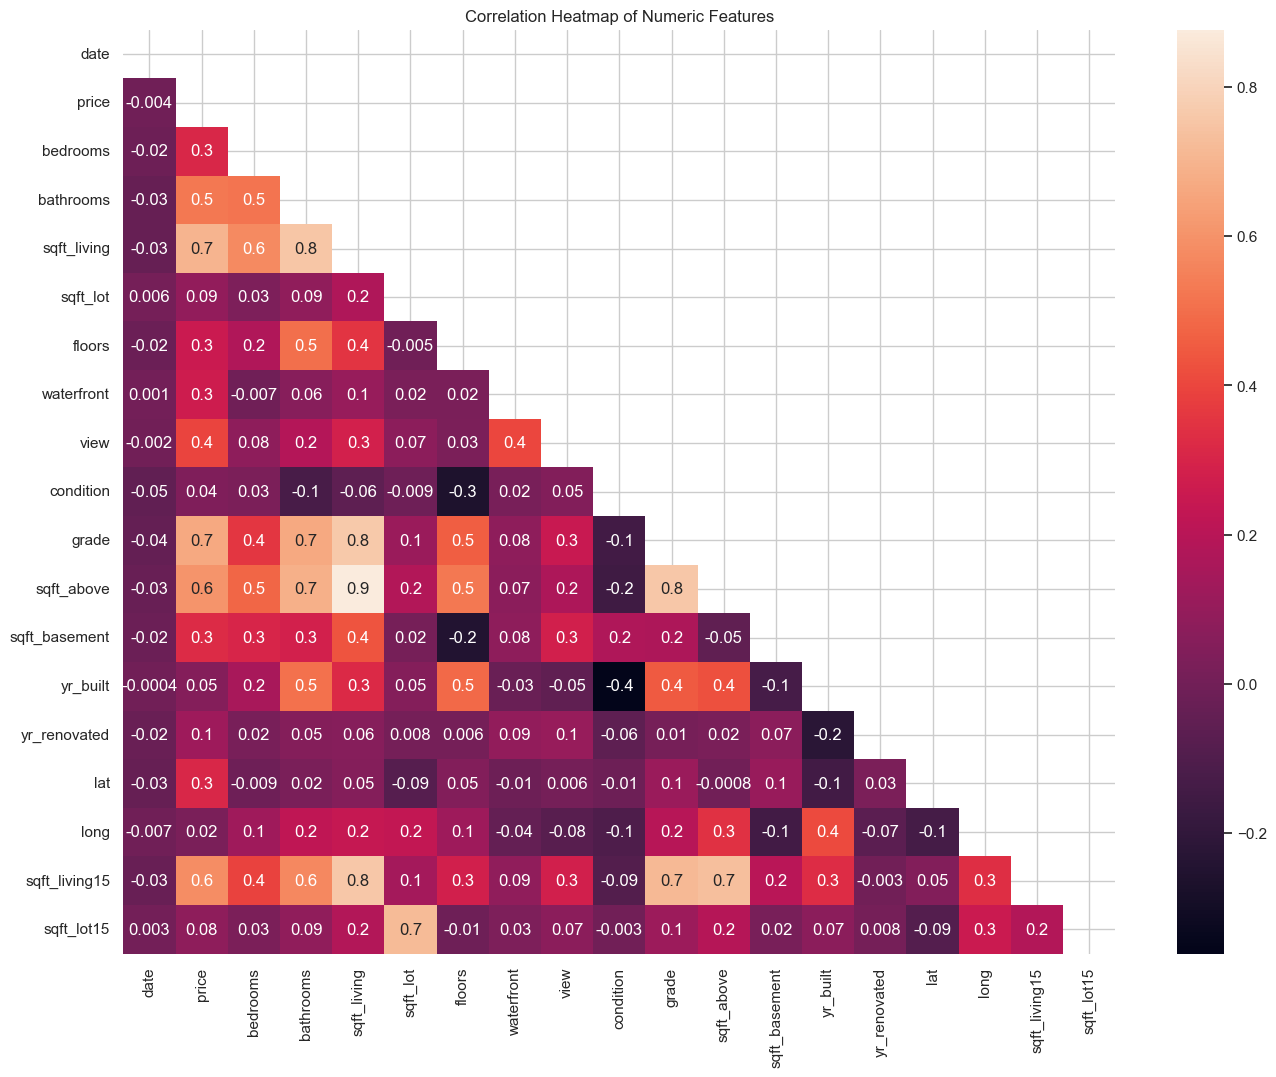

In [13]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".1"
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


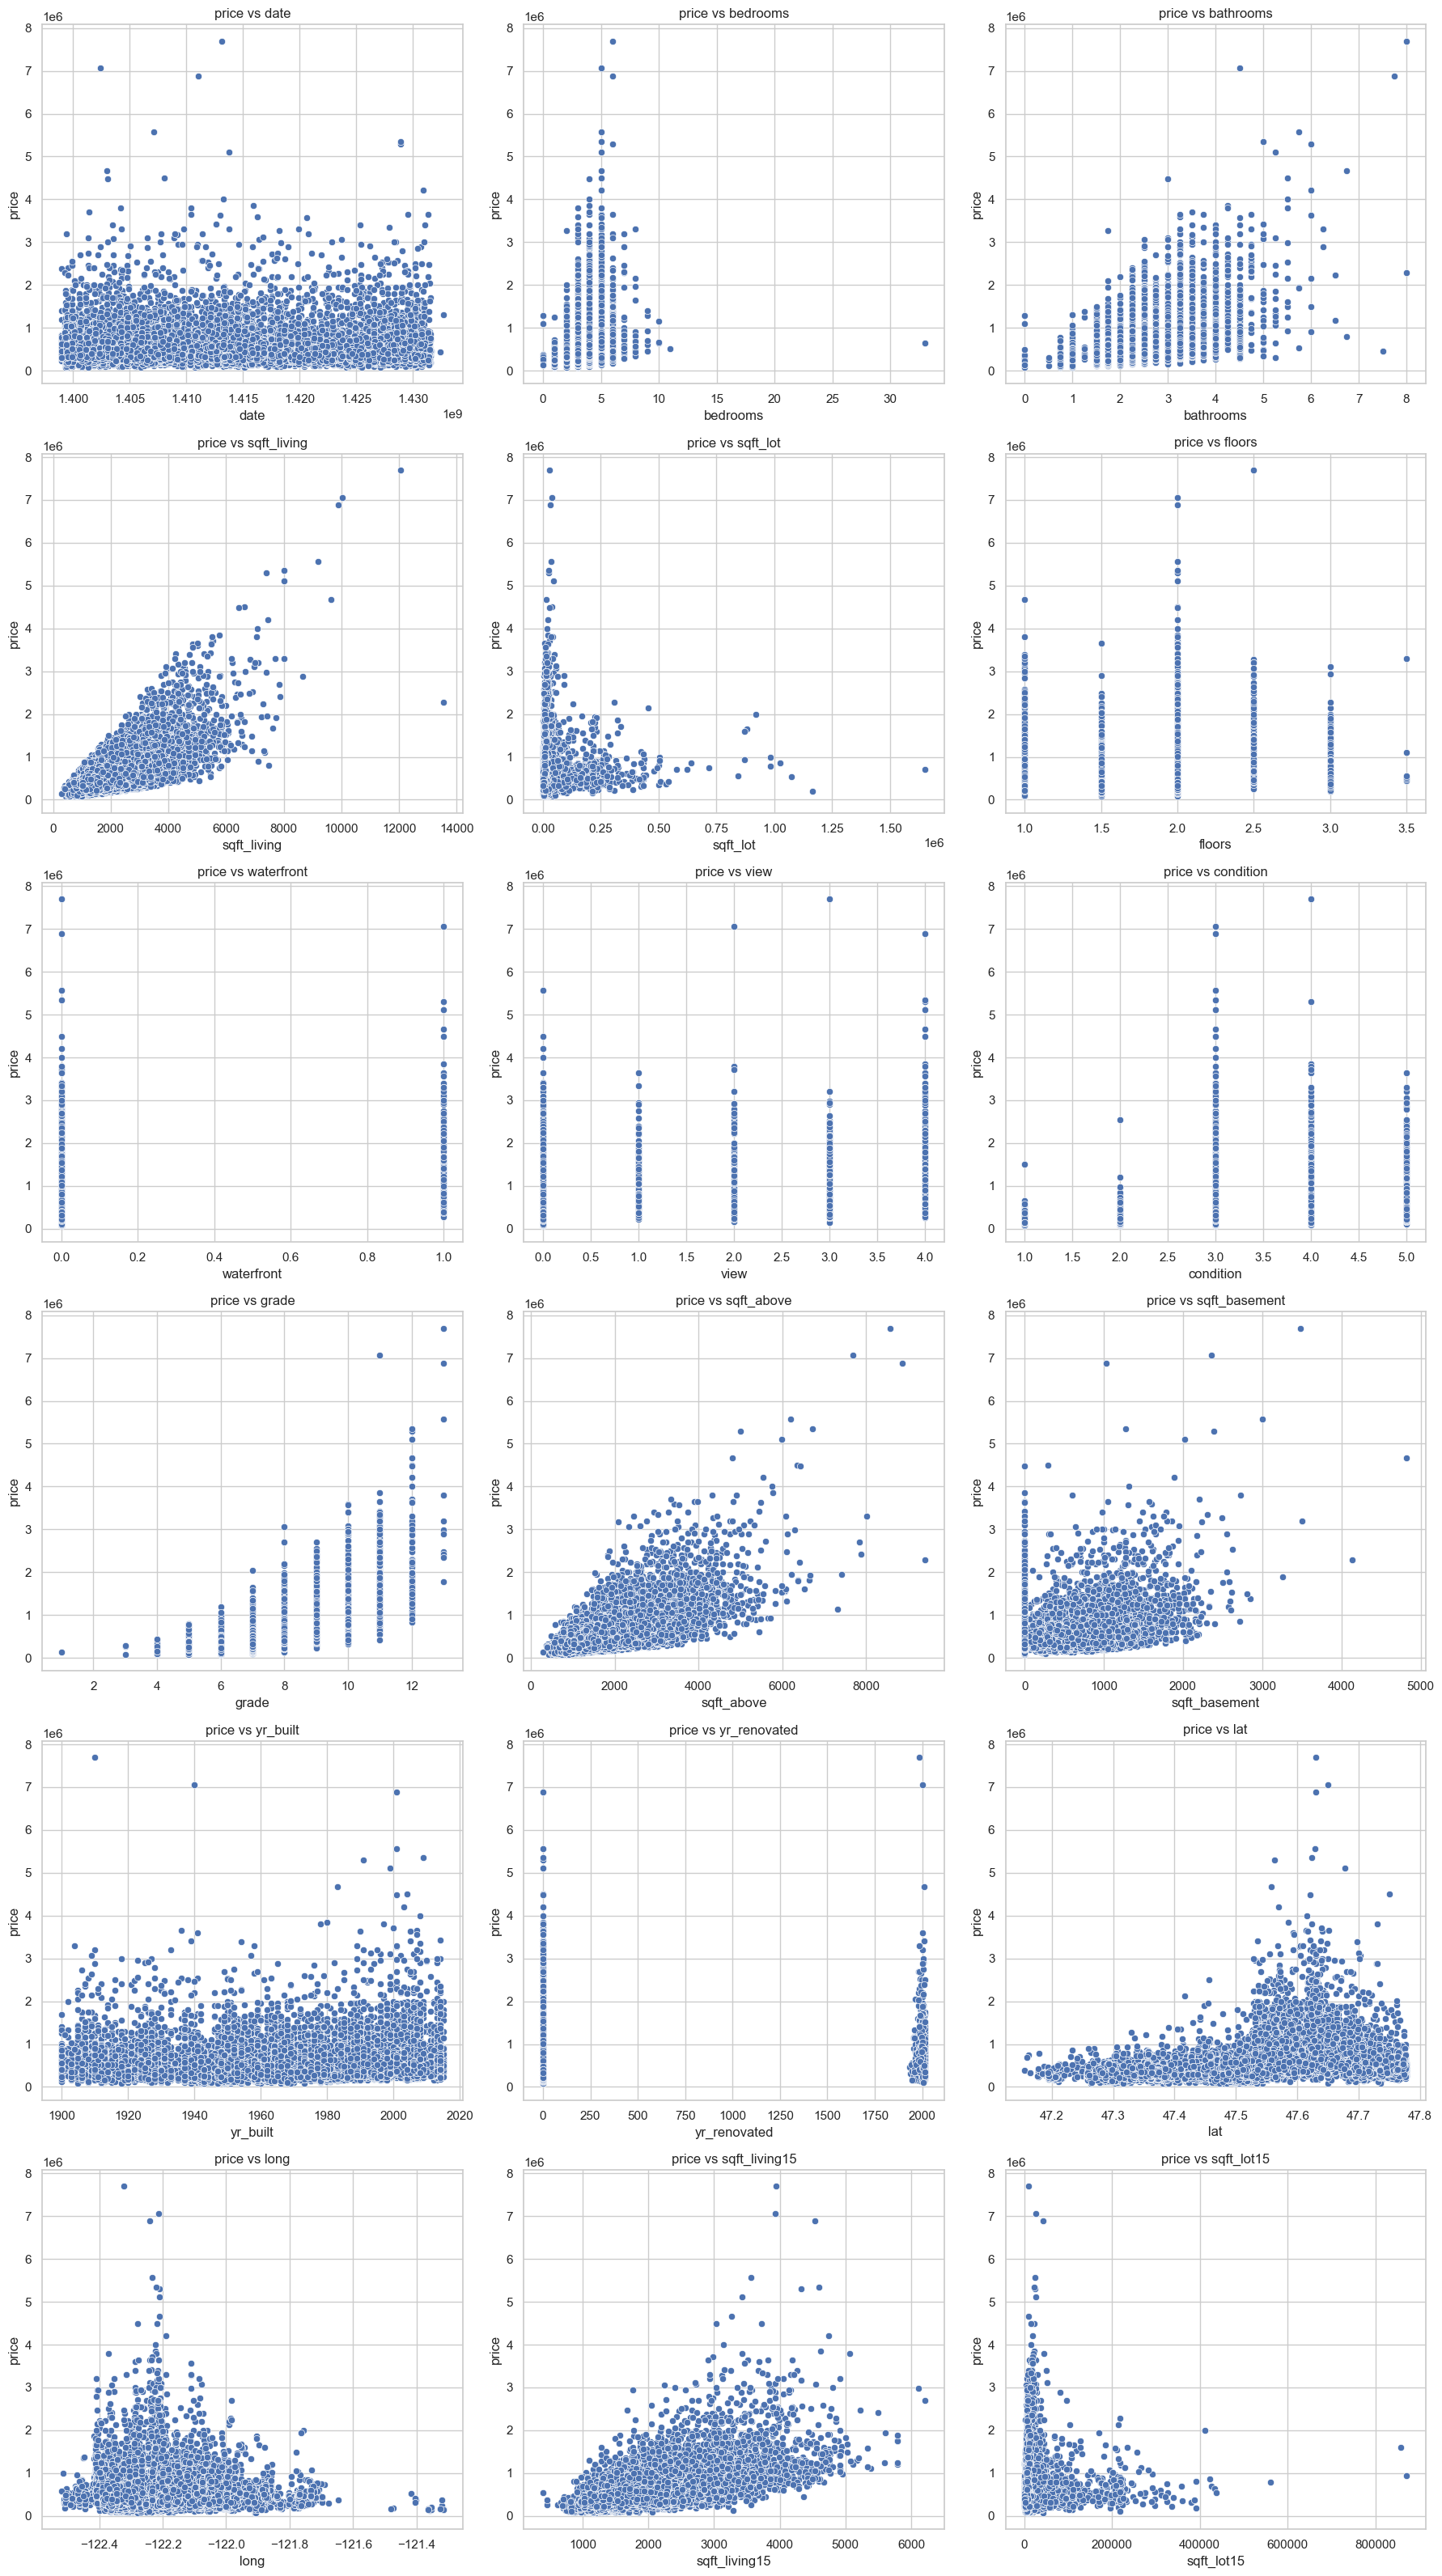

In [14]:
price_features = [col for col in df.columns if col != "price"]

fig, axes = plt.subplots(6, 3, figsize=(18, 32))
flat_axes = axes.flatten()

for ax, feature in zip(flat_axes, price_features):
    sns.scatterplot(
        data=df,
        x=feature,
        y="price",
        ax=ax,
    )
    ax.set_title(f"price vs {feature}")

plt.tight_layout()
plt.show()


#### Notes

- `price` is strongly right-skewed, so a later iteration may benefit from a log-transformed target.
- There exists some collinearity among features, for instance grade and all size metrics tend to move together, but also all the size metrics among each other (i.e. different types of `square footage`).
- Similarly, our target `price` seems to have a positive correlation with all size metrics; location also matters (`lat`/`long`)

### 3. Baseline OLS Regression


In [15]:
X = df.drop(columns="price")
y = df.price

X_scaled = StandardScaler().fit_transform(X)


In [16]:
lm = sm.OLS(y, X_scaled).fit()
lm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  price   R-squared (uncentered):                   0.220
Model:                            OLS   Adj. R-squared (uncentered):              0.220
Method:                 Least Squares   F-statistic:                              358.7
Date:                Thu, 19 Mar 2026   Prob (F-statistic):                        0.00
Time:                        23:11:00   Log-Likelihood:                     -3.1737e+05
No. Observations:               21613   AIC:                                  6.348e+05
Df Residuals:                   21596   BIC:                                  6.349e+05
Df Model:                          17                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1           1.33e+04   3938.613      3.377      0.001    5582.126     2.1e+04
x2         -3.187e+04   5038.134     -6.326      0.000   -4.17e+04    -2.2e+04
x3          3.264e+04   7182.441      4.545      0.000    1.86e+04    4.67e+04
x4          8.078e+04   4550.500     17.752      0.000    7.19e+04    8.97e+04
x5          5156.6241   5690.281      0.906      0.365   -5996.747    1.63e+04
x6           675.4452   5542.439      0.122      0.903   -1.02e+04    1.15e+04
x7          5.082e+04   4304.994     11.805      0.000    4.24e+04    5.93e+04
x8          3.768e+04   4682.005      8.047      0.000    2.85e+04    4.69e+04
x9          2.107e+04   4366.710      4.826      0.000    1.25e+04    2.96e+04
x10         1.147e+05   7250.609     15.817      0.000       1e+05    1.29e+05
x11         7.568e+04   4862.310     15.565      0.000    6.62e+04    8.52e+04
x12         2.604e+04   4467.999      5.827      0.000    1.73e+04    3.48e+04
x13        -7.211e+04   6067.947    -11.884      0.000    -8.4e+04   -6.02e+04
x14         9044.4295   4209.425      2.149      0.032     793.646    1.73e+04
x15         7.811e+04   4160.988     18.772      0.000       7e+04    8.63e+04
x16        -1.636e+04   4808.697     -3.403      0.001   -2.58e+04   -6939.138
x17         1.898e+04   6743.880      2.814      0.005    5759.935    3.22e+04
x18        -1.073e+04   5734.658     -1.872      0.061    -2.2e+04     505.995
==============================================================================
Omnibus:                    18572.637   Durbin-Watson:                   0.245
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1908223.730
Skew:                           3.625   Prob(JB):                         0.00
Kurtosis:                      48.458   Cond. No.                     1.40e+16
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The smallest eigenvalue is 5.64e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""